# Graph Beckmann Flow for $\Wass_1$

This notebook generates `fig:w1-graph-transport-flow`.  On a finite graph with edge lengths $\ell_e$, the graph Beckmann formulation is
$$
    \Wass_{1,G}(\alpha,\beta)=\min_m\left\{\sum_{e\in E}\ell_e |m_e|:\ \operatorname{div}_G m=\alpha-\beta\right\}.
$$
The figure compares two Delaunay discretizations.  The first panel uses a nearly regular set of vertices, while the second panel uses a denser nonuniform cloud sampled from a two-component Gaussian mixture.  In both cases, red and blue disks mark the positive and negative parts of the signed source term, and violet arrows show the optimal graph flow.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import linprog
from scipy.spatial import Delaunay

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY, BACKGROUND,
    DIRAC_MARKER_SIZE, MASS_MARKER_MIN_FACTOR, MASS_MARKER_MAX_FACTOR,
    TRANSPORT_LINE_MIN_WIDTH, POINT_EDGE_WIDTH,
    setup_matplotlib, figure_dir, save_pdf, remove_axes, padded_limits,
    interp_color,
)

setup_matplotlib()

NAME = "w1-graph-transport-flow"
OUT = figure_dir(NAME)


## Two Delaunay graphs and localized signed masses

The solver below is shared by both panels.  Each Delaunay edge is oriented by increasing vertex index, and the signed flow is represented by positive and negative edge variables in a linear program.  The first graph has a quasi-regular geometry, close to the standard geometric discretization used for finite-volume intuition; the second graph repeats the previous nonuniform construction with twice as many vertices, so the adaptive sampling is more visible while the flow remains readable.


In [2]:

def build_delaunay_edges(points):
    tri = Delaunay(points)
    edges = set()
    for simplex in tri.simplices:
        for a in range(3):
            for b in range(a + 1, 3):
                edges.add(tuple(sorted((int(simplex[a]), int(simplex[b])))))
    return sorted(edges)


def make_regular_points(seed=214, nx=8, ny=7):
    rng = np.random.default_rng(seed)
    xs = np.linspace(-1.20, 1.20, nx)
    ys = np.linspace(-0.76, 0.76, ny)
    points = np.array([(x, y) for y in ys for x in xs], dtype=float)
    points[:, 0] += 0.025 * rng.normal(size=len(points))
    points[:, 1] += 0.025 * rng.normal(size=len(points))
    # A tiny shear avoids perfectly symmetric triangulation choices while
    # keeping the graph visually close to a regular mesh.
    points[:, 0] += 0.07 * points[:, 1]
    return points


def sample_gaussian_cloud(rng, mean, cov, count):
    return rng.multivariate_normal(np.asarray(mean, dtype=float), np.asarray(cov, dtype=float), count)


def make_nonuniform_points(seed=715):
    rng = np.random.default_rng(seed)
    left = sample_gaussian_cloud(
        rng,
        mean=(-0.86, -0.08),
        cov=[[0.115, 0.035], [0.035, 0.085]],
        count=76,
    )
    right = sample_gaussian_cloud(
        rng,
        mean=(0.84, 0.16),
        cov=[[0.135, -0.050], [-0.050, 0.105]],
        count=68,
    )
    points = np.vstack([left, right])
    points -= points.mean(axis=0, keepdims=True)
    points[:, 0] *= 1.08
    points[:, 1] *= 1.18
    return points


def localized_signed_masses(points, source_center, target_center, k=6):
    source_idx = np.argsort(np.linalg.norm(points - source_center, axis=1))[:k]
    target_idx = np.argsort(np.linalg.norm(points - target_center, axis=1))[:k]
    source_weights = np.exp(-3.8 * np.linalg.norm(points[source_idx] - source_center, axis=1) ** 2)
    target_weights = np.exp(-3.6 * np.linalg.norm(points[target_idx] - target_center, axis=1) ** 2)
    source_weights = source_weights / source_weights.sum()
    target_weights = target_weights / target_weights.sum()

    alpha = np.zeros(len(points))
    beta = np.zeros(len(points))
    alpha[source_idx] = source_weights
    beta[target_idx] = target_weights
    return alpha, beta


def solve_graph_beckmann(points, source_center, target_center, k=6):
    edges = build_delaunay_edges(points)
    lengths = np.array([np.linalg.norm(points[i] - points[j]) for i, j in edges])
    alpha, beta = localized_signed_masses(points, source_center, target_center, k=k)
    r = alpha - beta

    incidence = np.zeros((len(points), len(edges)))
    for e, (i, j) in enumerate(edges):
        # The edge is oriented i -> j. This convention gives
        # (div_G m)_i = outgoing flow - incoming flow.
        incidence[i, e] = 1.0
        incidence[j, e] = -1.0

    assert abs(r.sum()) < 1e-14
    assert np.linalg.matrix_rank(incidence) == len(points) - 1

    objective = np.r_[lengths, lengths]
    constraints = np.c_[incidence, -incidence]
    res = linprog(
        objective,
        A_eq=constraints[:-1],
        b_eq=r[:-1],
        bounds=[(0.0, None)] * (2 * len(edges)),
        method="highs",
    )
    if not res.success:
        raise RuntimeError(res.message)
    flow = res.x[: len(edges)] - res.x[len(edges) :]
    assert np.linalg.norm(incidence @ flow - r, ord=np.inf) < 1e-9
    active_edges = np.flatnonzero(np.abs(flow) > 1e-9)
    flow_cost = float(np.dot(lengths, np.abs(flow)))

    # Independent check: graph Kantorovich--Rubinstein dual with f_0=0.
    A_ub = np.vstack([incidence.T, -incidence.T])
    b_ub = np.r_[lengths, lengths]
    A_eq = np.zeros((1, len(points)))
    A_eq[0, 0] = 1.0
    dual = linprog(
        -r,
        A_ub=A_ub,
        b_ub=b_ub,
        A_eq=A_eq,
        b_eq=np.zeros(1),
        bounds=[(None, None)] * len(points),
        method="highs",
    )
    if not dual.success:
        raise RuntimeError(dual.message)
    dual_cost = -float(dual.fun)
    assert abs(flow_cost - dual_cost) <= 1e-8 * max(1.0, flow_cost)

    return {
        "points": points,
        "edges": edges,
        "lengths": lengths,
        "alpha": alpha,
        "beta": beta,
        "flow": flow,
        "active_edges": active_edges,
        "flow_cost": flow_cost,
        "dual_cost": dual_cost,
    }


regular = solve_graph_beckmann(
    make_regular_points(),
    source_center=np.array([-0.94, 0.36]),
    target_center=np.array([0.98, -0.30]),
    k=6,
)
nonuniform = solve_graph_beckmann(
    make_nonuniform_points(),
    source_center=np.array([-1.20, 0.34]),
    target_center=np.array([1.15, -0.20]),
    k=6,
)

{
    "regular": (len(regular["points"]), len(regular["edges"]), len(regular["active_edges"]), regular["flow_cost"]),
    "nonuniform": (len(nonuniform["points"]), len(nonuniform["edges"]), len(nonuniform["active_edges"]), nonuniform["flow_cost"]),
}


{'regular': (56, 155, 20, 2.1490594504672327),
 'nonuniform': (144, 418, 36, 2.465127882669558)}

## Exported panels

The book uses two panels.  The first panel shows the same Beckmann construction on a quasi-regular Delaunay graph.  The second panel uses twice as many vertices as the previous nonuniform version.  Only circular markers are used for masses and vertices; arrow widths encode $\sqrt{|m_e|}$.


In [3]:

def graph_limits(data, pad=0.075):
    return padded_limits(data["points"], pad=pad)


def draw_base_graph(ax, data, *, alpha_edges=0.62, lw=0.56, vertex_scale=0.16):
    points = data["points"]
    segments = [[points[i], points[j]] for i, j in data["edges"]]
    rgba = (*to_rgb("#111111"), alpha_edges)
    ax.add_collection(LineCollection(segments, colors=[rgba], linewidths=lw, zorder=0))
    ax.scatter(
        points[:, 0], points[:, 1],
        s=DIRAC_MARKER_SIZE * vertex_scale, marker="o",
        color="#4d4d4d", edgecolor="none", linewidth=0, zorder=1,
    )


def mass_sizes(weights):
    sizes = np.zeros_like(weights)
    mask = weights > 0
    if np.any(mask):
        sizes[mask] = DIRAC_MARKER_SIZE * (0.55 + 1.10 * weights[mask] / weights[mask].max())
    return sizes


def draw_masses(ax, data, *, alpha_scale=1.0):
    points = data["points"]
    alpha = data["alpha"]
    beta = data["beta"]
    sa = mass_sizes(alpha) * alpha_scale
    sb = mass_sizes(beta) * alpha_scale
    ma = alpha > 0
    mb = beta > 0
    ax.scatter(points[ma, 0], points[ma, 1], s=sa[ma], marker="o", color=RED, edgecolor="none", linewidth=0, zorder=4)
    ax.scatter(points[mb, 0], points[mb, 1], s=sb[mb], marker="o", color=BLUE, edgecolor="none", linewidth=0, zorder=4)


def draw_flow(ax, data):
    points = data["points"]
    edges = data["edges"]
    flow = data["flow"]
    active_edges = data["active_edges"]
    max_flow = max(float(np.max(np.abs(flow))), 1e-15)
    for e in active_edges:
        i, j = edges[e]
        val = flow[e]
        start, end = (i, j) if val > 0 else (j, i)
        p0 = points[start].copy()
        p1 = points[end].copy()
        d = p1 - p0
        ell = np.linalg.norm(d)
        if ell == 0:
            continue
        u = d / ell
        p0 = p0 + 0.045 * u
        p1 = p1 - 0.045 * u
        normalized = abs(val) / max_flow
        width = TRANSPORT_LINE_MIN_WIDTH + (1.85 - TRANSPORT_LINE_MIN_WIDTH) * np.sqrt(normalized)
        arrow = FancyArrowPatch(
            p0,
            p1,
            arrowstyle="-|>",
            mutation_scale=5.8 + 2.5 * np.sqrt(normalized),
            linewidth=width,
            color=VIOLET,
            alpha=min(0.34 + 0.62 * normalized, 0.94),
            shrinkA=0,
            shrinkB=0,
            zorder=3,
        )
        ax.add_patch(arrow)


def finish_graph(ax, data):
    xlim_graph, ylim_graph = graph_limits(data)
    ax.set_xlim(*xlim_graph)
    ax.set_ylim(*ylim_graph)
    ax.set_aspect("equal")
    remove_axes(ax)


def draw_panel(data, filename, *, vertex_scale=0.16, edge_width=0.60, mass_scale=0.82):
    fig, ax = plt.subplots(figsize=(2.55, 2.16))
    draw_base_graph(ax, data, alpha_edges=0.64, lw=edge_width, vertex_scale=vertex_scale)
    draw_flow(ax, data)
    draw_masses(ax, data, alpha_scale=mass_scale)
    finish_graph(ax, data)
    save_pdf(fig, OUT / filename, pad_inches=0.038)
    plt.close(fig)


draw_panel(regular, "regular.pdf", vertex_scale=0.17, edge_width=0.62, mass_scale=0.82)
draw_panel(nonuniform, "nonuniform.pdf", vertex_scale=0.10, edge_width=0.46, mass_scale=0.82)

# Compatibility preview: a compact combined thumbnail for the notebook gallery.
fig, axes = plt.subplots(1, 2, figsize=(5.1, 2.14))
for ax, data, vertex_scale, edge_width in [
    (axes[0], regular, 0.17, 0.62),
    (axes[1], nonuniform, 0.10, 0.46),
]:
    draw_base_graph(ax, data, alpha_edges=0.64, lw=edge_width, vertex_scale=vertex_scale)
    draw_flow(ax, data)
    draw_masses(ax, data, alpha_scale=0.82)
    finish_graph(ax, data)
plt.subplots_adjust(wspace=0.04, left=0.01, right=0.99, bottom=0.01, top=0.99)
save_pdf(fig, OUT / "flow.pdf", pad_inches=0.030)
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(thumb_dir / f"{NAME}.png", dpi=190, bbox_inches="tight", pad_inches=0.025)
plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


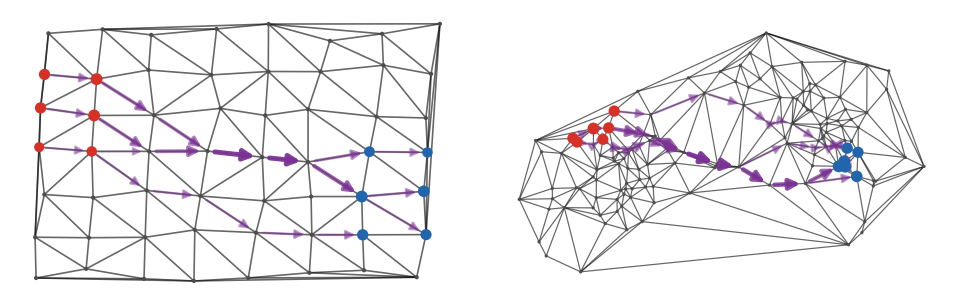

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/w1-graph-transport-flow.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/w1-graph-transport-flow.png")
display(Image(filename=str(_thumb)))
